In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from pathlib import Path
import json
import random

In [3]:
images_dir = Path("C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/train/images")
labels_dir = Path("C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/train/labels")

pairs = []
for labl in labels_dir.iterdir():
    if labl.suffix == ".txt":
        image_file = labl.stem + ".jpg"
        image_path = images_dir / image_file
        pairs.append((image_path.as_posix(), labl.as_posix()))

In [28]:
def load_and_split(ime_path,lel_path):
    image= cv2.imread(ime_path)
    H,W,_ = image.shape
    with open(lel_path, "r") as f:
        line = f.readline().strip().split()
        class_id = int(line[0])
        x_center = float(line[1])
        y_center = float(line[2])
        w = float(line[3])
        h = float(line[4])

    x_center *= W
    y_center *= H
    box_w = w * W
    box_h = h * H
    x1 = int(x_center - box_w / 2)
    y1 = int(y_center - box_h / 2)
    x2 = int(x_center + box_w / 2)
    y2 = int(y_center + box_h / 2)

    crop=image[y1:y2,x1:x2]

    return crop, class_id


In [66]:
x_test,y_test=[],[]
for img,lbl in pairs:
    crop,idt=load_and_split(img,lbl)
    crop = cv2.resize(crop, (64, 64))
    x_test.append(crop)
    y_test.append(idt)
X_final=np.array(x_test,dtype="float32")/255.0
y_final=np.array(y_test,dtype=np.int32)

In [67]:
y_final[900]

np.int32(5)

In [33]:
index_mapping = {
    0: 2,   # ALIF -> aleff
    1: 3,   # BAA -> bb
    2: 23,  # TA -> ta
    3: 25,  # THA -> thaa
    4: 12,  # JEEM -> jeem
    5: 11,  # HAA -> haa
    6: 14,  # KHAA -> khaa
    7: 4,   # DELL -> dal
    8: 26,  # DHELL -> thal
    9: 19,  # RAA -> ra
    10: 31, # ZAY -> zay
    11: 21, # SEEN -> seen
    12: 22, # SHEEN -> sheen
    13: 20, # SAD -> saad
    14: 6,  # DAD -> dhad
    15: 24, # TAA -> taa
    16: 5,  # DHAA -> dha
    17: 0,  # AYN -> ain
    18: 9,  # GHAYN -> ghain
    19: 7,  # FAA -> fa
    20: 8,  # QAAF -> qaaf
    21: 13, # KAAF -> kaf
    22: 16, # LAAM -> laam
    23: 17, # MEEM -> meem
    24: 18, # NOON -> nun
    25: 10, # HA -> ha
    26: 28, # WAW -> waw
    27: 29, # YA -> ya
}


In [68]:
y_mapped = np.array([index_mapping[label] for label in y_final])

In [69]:
from tensorflow.keras.utils import to_categorical
y_mapped[900]
y_mapped_categorical=to_categorical(y_mapped, num_classes=32)

In [116]:
model = tf.keras.models.load_model(r"C:\Users\ibrah\Downloads\arabic_sign_model.h5")
y_pred_probs = model_new.predict(X_final)
y_pred = np.argmax(y_pred_probs, axis=1)

with open(r"C:\Users\ibrah\Downloads\class_names.json", "r") as f:
    class_names = json.load(f)

146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


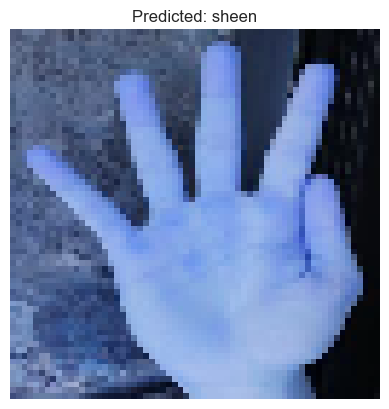

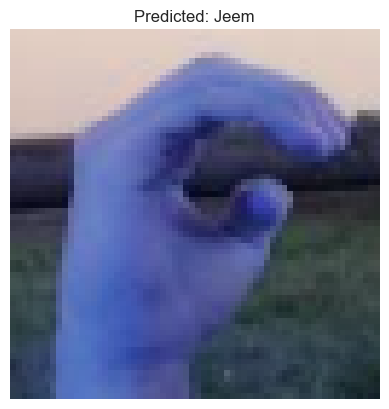

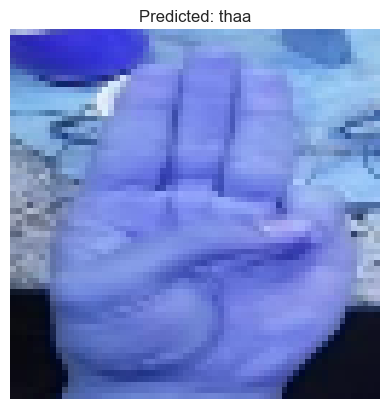

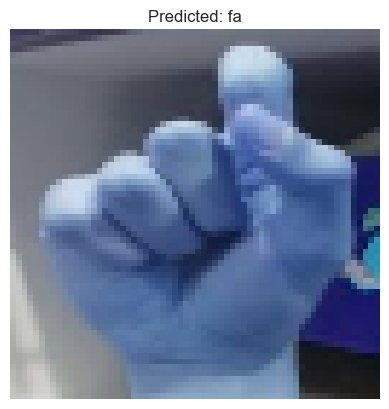

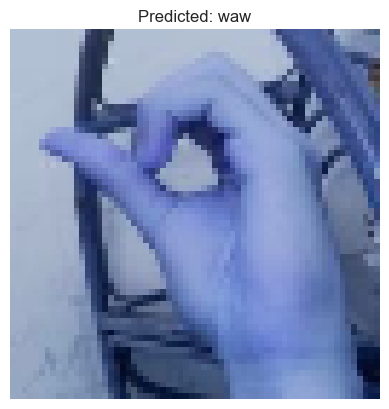

In [117]:
for i in random.sample(range(len(X_final)), 5):
    plt.imshow(X_final[i])
    plt.axis("off")
    plt.title(f"Predicted: {class_names[int(y_pred[i])]}")
    plt.show()

**Now More Training from the data set we got**

In [50]:
valid_images_dir= Path("C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/valid/images")
valid_label_dir= Path("C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/valid/labels")

val_pairs = []
for labl in valid_label_dir.iterdir():
    if labl.suffix == ".txt":
        image_file = labl.stem + ".jpg"
        image_path = valid_images_dir / image_file
        val_pairs.append((image_path.as_posix(), labl.as_posix()))

In [51]:
val_pairs[1]

('C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/valid/images/IMG_20210609_185131_jpg.rf.694078212c691632597bcaa1fdf1841a.jpg',
 'C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/valid/labels/IMG_20210609_185131_jpg.rf.694078212c691632597bcaa1fdf1841a.txt')

In [70]:
x_valid_test,y_valid_test=[],[]
for img, lbl in val_pairs:
    crop, idt = load_and_split(img, lbl)

    # Skip if crop is None or empty
    if crop is None or crop.size == 0:
        print("Skipping:", img, lbl)
        continue

    crop = cv2.resize(crop, (64, 64))
    x_valid_test.append(crop)
    y_valid_test.append(idt)
X_valid=np.array(x_valid_test,dtype="float32")/255.0
y_valid=np.array(y_valid_test,dtype=np.int32)
y_valid_mapped = np.array([index_mapping[label] for label in y_valid])

Skipping: C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/valid/images/IMG_20210616_001504_jpg.rf.61c29b4f5ba3958249ce80c1295f93f0.jpg C:/Users/ibrah/Downloads/archive(2)/unaugmented/416/valid/labels/IMG_20210616_001504_jpg.rf.61c29b4f5ba3958249ce80c1295f93f0.txt


In [76]:
y_vaid_cat = to_categorical(y_valid_mapped, num_classes=32)

In [78]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [79]:
history = model.fit(
    X_final, y_mapped_categorical,
    validation_data=(X_valid, y_vaid_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5319 - loss: 1.5805 - val_accuracy: 0.8113 - val_loss: 0.6086 - learning_rate: 0.0010
Epoch 2/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7302 - loss: 0.8116 - val_accuracy: 0.9022 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 3/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8160 - loss: 0.5457 - val_accuracy: 0.9321 - val_loss: 0.2656 - learning_rate: 0.0010
Epoch 4/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8628 - loss: 0.4071 - val_accuracy: 0.9425 - val_loss: 0.1916 - learning_rate: 0.0010
Epoch 5/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8865 - loss: 0.3304 - val_accuracy: 0.9471 - val_loss: 0.1768 - learning_rate: 0.0010
Epoch 6/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8998 - loss: 0.2907 - val_accuracy: 0.9597 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 7/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9170 - loss: 0.

In [81]:
model.save(r"C:\Users\ibrah\Downloads\arabic_sign_model_v2.keras")

In [87]:
model_old= tf.keras.models.load_model(r"C:\Users\ibrah\Downloads\arabic_sign_model.h5")
model_new= tf.keras.models.load_model(r"C:\Users\ibrah\Downloads\arabic_sign_model_v2.keras")

model_old.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
loss, acc = model_old.evaluate(X_valid, y_vaid_cat)
print("Loaded old model accuracy:", acc)
loss, acc1 = model_new.evaluate(X_valid, y_vaid_cat)
print("Loaded new model accuracy:", acc1)


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5052 - loss: 2.2127
Loaded old model accuracy: 0.5051783919334412
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9839 - loss: 0.0679
Loaded new model accuracy: 0.9838895201683044


In [88]:
test_img_dir=Path(r"C:\Users\ibrah\Downloads\archive(2)\unaugmented\416\test\images")
test_label_dir=Path(r"C:\Users\ibrah\Downloads\archive(2)\unaugmented\416\test\labels")

test_pairs = []
for labl in test_label_dir.iterdir():
    if labl.suffix == ".txt":
        image_file = labl.stem + ".jpg"
        image_path = test_img_dir / image_file
        test_pairs.append((image_path.as_posix(), labl.as_posix()))

In [103]:
print(len(test_pairs))

290


In [137]:
x_test_pre, y_test_pre = [], []
for img, lbl in test_pairs:
    crop, idt = load_and_split(img, lbl)

    # Skip if crop is None or empty
    if crop is None or crop.size == 0:
        print("Skipping:", img, lbl)
        continue

    crop = cv2.resize(crop, (64, 64))
    x_test_pre.append(crop)
    y_test_pre.append(idt)

X_test = np.array(x_test_pre, dtype="float32") / 255.0
y_test = np.array(y_test_pre, dtype=np.int32)

# ✅ FIX: use y_test here, not y_valid
y_test_mapped = np.array([index_mapping[label] for label in y_test])

# One-hot encode
Y_test = to_categorical(y_test_mapped, num_classes=32)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)


X_test shape: (290, 64, 64, 3)
Y_test shape: (290, 32)


In [138]:
y_test_pred=model_new.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


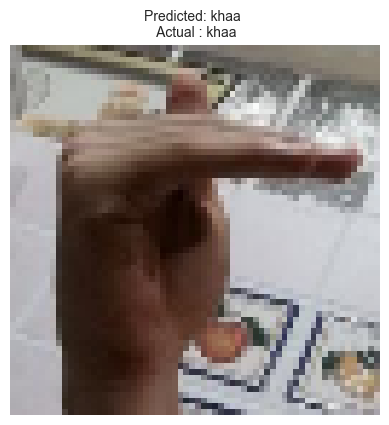

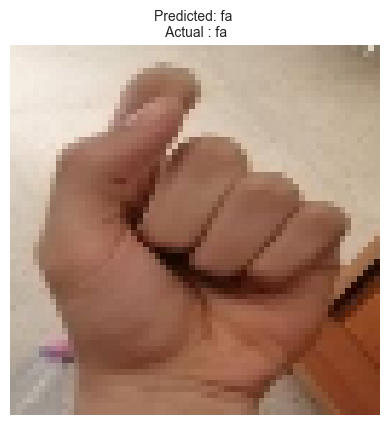

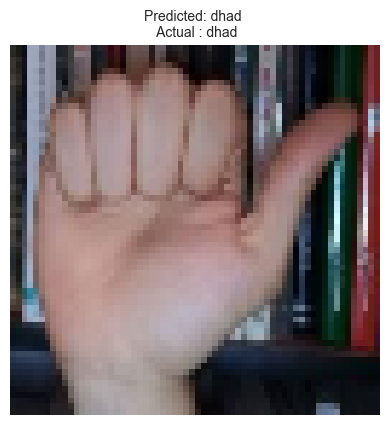

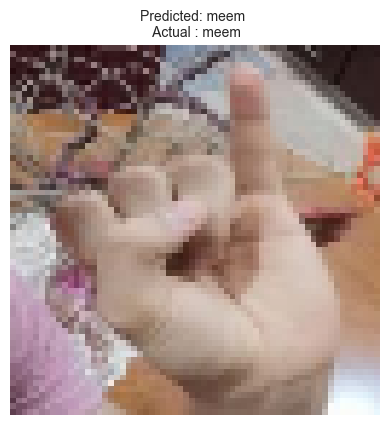

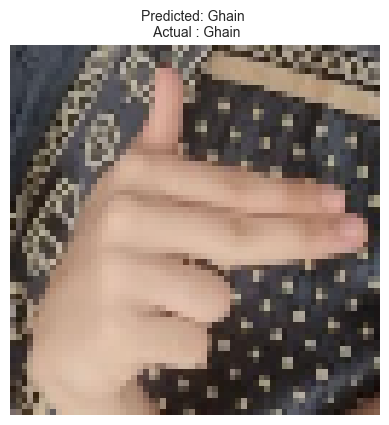

In [148]:
import cv2
import matplotlib.pyplot as plt
import random
import json
import numpy as np

y_pred = np.argmax(y_test_pred, axis=1)

with open(r"C:\Users\ibrah\Downloads\class_names.json", "r") as f:
    class_names = json.load(f)

for i in random.sample(range(len(X_test)), 5):
    # Convert normalized float32 BGR → RGB
    img_rgb = X_test[i][:, :, ::-1]   # reverse last axis (BGR → RGB)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Predicted: {class_names[int(y_pred[i])]} \n Actual : {class_names[int(y_test_mapped[i])]}",
              fontsize=10)
    plt.show()

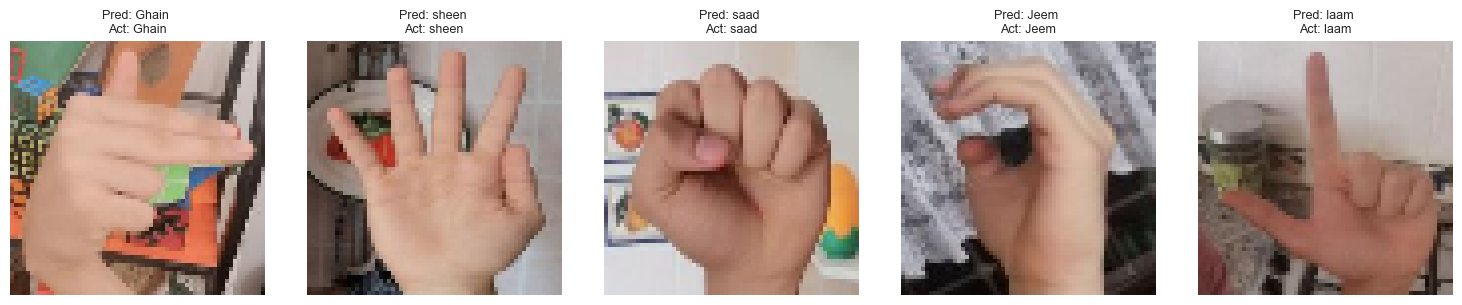

In [175]:
import matplotlib.pyplot as plt
import random
import numpy as np

# pick random indices
num_samples = 5
indices = random.sample(range(len(X_test)), num_samples)

# create subplots (1 row, num_samples cols)
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for ax, i in zip(axes, indices):
    # convert from BGR -> RGB
    img_rgb = X_test[i][:, :, ::-1]

    ax.imshow(img_rgb)
    ax.axis("off")
    ax.set_title(
        f"Pred: {class_names[int(y_pred[i])]} \nAct: {class_names[int(y_test_mapped[i])]}",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(r"C:\Users\ibrah\Downloads\saved tests\saved_test11.png")
plt.show()



In [144]:
loss, acc = model_new.evaluate(X_test, Y_test)  # if one-hot
print(f"Test Accuracy: {acc:.4f}, Test Loss: {loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9690 - loss: 0.1025
Test Accuracy: 0.9690, Test Loss: 0.1025
